In [2]:
!pip install dagshub mlflow optuna -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 1.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.1/273.1 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 89.0 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 68.0 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 44.7 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.2/68.2 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
import mlflow.sklearn
import dagshub
from sklearn.linear_model import LogisticRegression, RidgeClassifier, SGDClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold
from kaggle_secrets import UserSecretsClient
import warnings
warnings.filterwarnings('ignore')

dagshub.init (
    repo_owner="sophyrise",
    repo_name='ieee-cis-fraud-detection',
    mlflow=True
)

mlflow.set_experiment("Decision Trees")
print("✅ MLflow tracking URI:", mlflow.get_tracking_uri())

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

Output()



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=270a2533-82f3-49cb-ac93-93aaad202ce9&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=65a58e1a0806823608dbe6ef4b7d6269db9f79826f10d0cc7a1448adb258254e




Accessing as sophyrise

Initialized MLflow to track repo "sophyrise/ieee-cis-fraud-detection"

Repository sophyrise/ieee-cis-fraud-detection initialized!

✅ MLflow tracking URI: https://dagshub.com/sophyrise/ieee-cis-fraud-detection.mlflow


# **Cleaning**

In [4]:
with mlflow.start_run(run_name="DecisionTrees_Cleaning"):
    import gc
    import numpy as np
    import pandas as pd

    DATA_DIR = "/kaggle/input/competitions/ieee-fraud-detection"
    TXN_MISSING_THRESHOLD = 0.80
    ID_MISSING_THRESHOLD = 0.95
    NEAR_CONSTANT_THRESHOLD = 0.99

    # load
    train_txn = pd.read_csv(f"{DATA_DIR}/train_transaction.csv")
    train_id  = pd.read_csv(f"{DATA_DIR}/train_identity.csv")
    test_txn  = pd.read_csv(f"{DATA_DIR}/test_transaction.csv")
    test_id   = pd.read_csv(f"{DATA_DIR}/test_identity.csv")

    # fix id-01 vs id_01
    test_id.columns = test_id.columns.str.replace("-", "_", regex=False)

    # merge
    train = train_txn.merge(train_id, on="TransactionID", how="left")
    test  = test_txn.merge(test_id, on="TransactionID", how="left")

    del train_txn, train_id, test_txn, test_id
    gc.collect()

    # split target
    y_train = train["isFraud"].astype(np.int8)
    X_train = train.drop(columns=["isFraud", "TransactionID"])
    X_test  = test.drop(columns=["TransactionID"])

    del train, test
    gc.collect()

    # drop high-missing
    id_like_cols = [c for c in X_train.columns if c.startswith("id_") or c in ["DeviceType", "DeviceInfo"]]
    txn_like_cols = [c for c in X_train.columns if c not in id_like_cols]
    missing_ratio = X_train.isnull().mean()

    drop_txn = [c for c in txn_like_cols if missing_ratio[c] > TXN_MISSING_THRESHOLD]
    drop_id  = [c for c in id_like_cols if missing_ratio[c] > ID_MISSING_THRESHOLD]
    drop_missing = drop_txn + drop_id

    X_train = X_train.drop(columns=drop_missing)
    X_test  = X_test.drop(columns=[c for c in drop_missing if c in X_test.columns])

    # drop near-constant
    near_constant_cols = []
    for col in X_train.columns:
        top_freq = X_train[col].value_counts(dropna=False, normalize=True).iloc[0]
        if top_freq > NEAR_CONSTANT_THRESHOLD:
            near_constant_cols.append(col)

    X_train = X_train.drop(columns=near_constant_cols)
    X_test  = X_test.drop(columns=[c for c in near_constant_cols if c in X_test.columns])

    # align test columns
    for col in X_train.columns:
        if col not in X_test.columns:
            X_test[col] = np.nan
    X_test = X_test[X_train.columns]

    # log
    mlflow.log_param("txn_missing_threshold", TXN_MISSING_THRESHOLD)
    mlflow.log_param("id_missing_threshold", ID_MISSING_THRESHOLD)
    mlflow.log_param("near_constant_threshold", NEAR_CONSTANT_THRESHOLD)

    mlflow.log_metric("train_rows", int(X_train.shape[0]))
    mlflow.log_metric("test_rows", int(X_test.shape[0]))
    mlflow.log_metric("final_features", int(X_train.shape[1]))
    mlflow.log_metric("fraud_rate", float(y_train.mean()))
    mlflow.log_metric("dropped_missing_cols", int(len(drop_missing)))
    mlflow.log_metric("dropped_near_constant_cols", int(len(near_constant_cols)))

    print(f"X_train_clean: {X_train.shape}")
    print(f"X_test_clean:  {X_test.shape}")

    # keep for next cells
    X_train_clean = X_train
    X_test_clean = X_test
    y_train_clean = y_train

X_train_clean: (590540, 353)
X_test_clean:  (506691, 353)
🏃 View run DecisionTrees_Cleaning at: https://dagshub.com/sophyrise/ieee-cis-fraud-detection.mlflow/#/experiments/2/runs/ee673327ee3c41df82383d75e454649a
🧪 View experiment at: https://dagshub.com/sophyrise/ieee-cis-fraud-detection.mlflow/#/experiments/2


# **Feature Engineering**

In [5]:
with mlflow.start_run(run_name="DecisionTree_FeatureEngineering"):
    from sklearn.impute import SimpleImputer

    X_train = X_train_clean.copy()
    X_test = X_test_clean.copy()
    y_train = y_train_clean.copy()

    X_train["TransactionAmt_log"] = np.log1p(X_train["TransactionAmt"].clip(lower=0))
    X_test["TransactionAmt_log"] = np.log1p(X_test["TransactionAmt"].clip(lower=0))

    X_train["hour_sin"] = np.sin(2 * np.pi * ((X_train["TransactionDT"] // 3600) % 24) / 24)
    X_train["hour_cos"] = np.cos(2 * np.pi * ((X_train["TransactionDT"] // 3600) % 24) / 24)
    X_test["hour_sin"] = np.sin(2 * np.pi * ((X_test["TransactionDT"] // 3600) % 24) / 24)
    X_test["hour_cos"] = np.cos(2 * np.pi * ((X_test["TransactionDT"] // 3600) % 24) / 24)

    X_train = X_train.drop(columns=["TransactionDT"], errors="ignore")
    X_test = X_test.drop(columns=["TransactionDT"], errors="ignore")

    cat_cols = X_train.select_dtypes(include=["object"]).columns.tolist()
    num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

    num_imp = SimpleImputer(strategy="median")
    X_train[num_cols] = num_imp.fit_transform(X_train[num_cols])
    X_test[num_cols] = num_imp.transform(X_test[num_cols])

    cat_maps = {}
    for c in cat_cols:
        uniq = pd.Series(X_train[c].astype(str).unique())
        mapping = {v: i for i, v in enumerate(uniq)}
        cat_maps[c] = mapping
        X_train[c] = X_train[c].astype(str).map(mapping).fillna(-1).astype(np.int32)
        X_test[c] = X_test[c].astype(str).map(mapping).fillna(-1).astype(np.int32)

    X_test = X_test.reindex(columns=X_train.columns, fill_value=-1)

    mlflow.log_metric("features_after_fe", int(X_train.shape[1]))
    mlflow.log_metric("cat_cols_encoded", int(len(cat_cols)))

    print("X_train_fe:", X_train.shape)
    print("X_test_fe: ", X_test.shape)

    X_train_fe_dt = X_train
    X_test_fe_dt = X_test
    y_train_fe_dt = y_train

X_train_fe: (590540, 355)
X_test_fe:  (506691, 355)
🏃 View run DecisionTree_FeatureEngineering at: https://dagshub.com/sophyrise/ieee-cis-fraud-detection.mlflow/#/experiments/2/runs/2da2460bca2c47e2b506df99965fce3a
🧪 View experiment at: https://dagshub.com/sophyrise/ieee-cis-fraud-detection.mlflow/#/experiments/2


In [6]:
print(X_train_fe_dt.shape, X_test_fe_dt.shape)
assert X_train_fe_dt.shape[1] == X_test_fe_dt.shape[1]
print("object cols left:", X_train_fe_dt.select_dtypes(include=["object"]).shape[1])

(590540, 355) (506691, 355)
object cols left: 0


# **Feature Selection**

In [7]:
with mlflow.start_run(run_name="DecisionTree_FeatureSelection"):
    X_train = X_train_fe_dt.copy()
    X_test = X_test_fe_dt.copy()

    X_train = X_train.replace([np.inf, -np.inf], np.nan).fillna(0)
    X_test = X_test.replace([np.inf, -np.inf], np.nan).fillna(0)

    nu = X_train.nunique(dropna=False)
    const_cols = nu[nu <= 1].index.tolist()
    X_train = X_train.drop(columns=const_cols, errors="ignore")
    X_test = X_test.drop(columns=const_cols, errors="ignore")

    num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

    sample_n = min(120_000, len(X_train))
    idx = np.random.RandomState(42).choice(len(X_train), size=sample_n, replace=False)
    corr = X_train.iloc[idx][num_cols].corr().abs()

    upper = corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1))
    drop_corr = [c for c in upper.columns if (upper[c] > 0.98).any()]

    X_train = X_train.drop(columns=drop_corr, errors="ignore")
    X_test = X_test.drop(columns=drop_corr, errors="ignore")

    X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

    mlflow.log_metric("dropped_const", len(const_cols))
    mlflow.log_metric("dropped_corr", len(drop_corr))
    mlflow.log_metric("features_after_fs", int(X_train.shape[1]))

    print("X_train_fs:", X_train.shape)

    X_train_final_dt = X_train
    X_test_final_dt = X_test

X_train_fs: (590540, 306)
🏃 View run DecisionTree_FeatureSelection at: https://dagshub.com/sophyrise/ieee-cis-fraud-detection.mlflow/#/experiments/2/runs/5259ad2fdec94748ae8e52162b2b9f07
🧪 View experiment at: https://dagshub.com/sophyrise/ieee-cis-fraud-detection.mlflow/#/experiments/2


In [8]:
print(X_train_final_dt.shape, X_test_final_dt.shape)
assert X_train_final_dt.shape[1] == X_test_final_dt.shape[1]

(590540, 306) (506691, 306)


# **Training**

In [9]:
from sklearn.model_selection import train_test_split

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_final_dt, y_train_fe_dt,
    test_size=0.2, random_state=42, stratify=y_train_fe_dt
)
print(f"Train: {X_tr.shape}, Val: {X_val.shape}")
print(f"Fraud rate train: {y_tr.mean():.4f}, val: {y_val.mean():.4f}")

Train: (472432, 306), Val: (118108, 306)
Fraud rate train: 0.0350, val: 0.0350


In [10]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score
import numpy as np
import pandas as pd
import mlflow
import mlflow.sklearn
import warnings
warnings.filterwarnings('ignore')

# Shallow tree — will underfit
with mlflow.start_run(run_name="DT_Baseline"):
    mlflow.log_param("max_depth", 3)
    mlflow.log_param("criterion", "gini")
    mlflow.log_param("class_weight", None)
    mlflow.log_param("note", "very shallow tree — expect underfitting")

    clf = DecisionTreeClassifier(max_depth=3, random_state=42)
    clf.fit(X_tr, y_tr)

    train_auc = roc_auc_score(y_tr, clf.predict_proba(X_tr)[:, 1])
    val_auc   = roc_auc_score(y_val, clf.predict_proba(X_val)[:, 1])

    mlflow.log_metric("train_auc", round(train_auc, 5))
    mlflow.log_metric("val_auc",   round(val_auc,   5))
    mlflow.log_metric("overfit_gap", round(train_auc - val_auc, 5))

    print(f"[Baseline] Train: {train_auc:.4f} | Val: {val_auc:.4f} | Gap: {train_auc - val_auc:.4f}")
    print("  -> depth=3 on 306 features clearly underfits")

[Baseline] Train: 0.6914 | Val: 0.6878 | Gap: 0.0037
  -> depth=3 on 306 features clearly underfits
🏃 View run DT_Baseline at: https://dagshub.com/sophyrise/ieee-cis-fraud-detection.mlflow/#/experiments/2/runs/21cb9c4b85f446d8a7b0141152c5d2b5
🧪 View experiment at: https://dagshub.com/sophyrise/ieee-cis-fraud-detection.mlflow/#/experiments/2


In [11]:
depth_results = []
for depth in [3, 5, 10, 15, 20, None]:
    label = str(depth)
    with mlflow.start_run(run_name=f"DT_depth_{label}"):
        mlflow.log_param("max_depth", label)
        mlflow.log_param("criterion", "gini")
        mlflow.log_param("class_weight", "balanced")

        clf = DecisionTreeClassifier(max_depth=depth, class_weight="balanced",
                                      random_state=42)
        clf.fit(X_tr, y_tr)

        train_auc = roc_auc_score(y_tr, clf.predict_proba(X_tr)[:, 1])
        val_auc   = roc_auc_score(y_val, clf.predict_proba(X_val)[:, 1])
        gap = train_auc - val_auc

        mlflow.log_metric("train_auc",   round(train_auc, 5))
        mlflow.log_metric("val_auc",     round(val_auc,   5))
        mlflow.log_metric("overfit_gap", round(gap, 5))
        mlflow.log_metric("n_leaves",    int(clf.get_n_leaves()))

        depth_results.append({"max_depth": label, "train_auc": train_auc,
                               "val_auc": val_auc, "gap": gap})
        print(f"  depth={label:<5} | Train: {train_auc:.4f} | Val: {val_auc:.4f} | Gap: {gap:.4f}")

depth_df = pd.DataFrame(depth_results).set_index("max_depth")
best_depth_label = depth_df["val_auc"].idxmax()
best_depth_val = None if best_depth_label == "None" else int(best_depth_label)
print(f"\n-> Best depth: {best_depth_label}")
print(depth_df.to_string())
# depth=None will sand val_auc dropping — classic overfit

  depth=3     | Train: 0.7737 | Val: 0.7761 | Gap: -0.0024
🏃 View run DT_depth_3 at: https://dagshub.com/sophyrise/ieee-cis-fraud-detection.mlflow/#/experiments/2/runs/26804456a3dc49439982324039d085cc
🧪 View experiment at: https://dagshub.com/sophyrise/ieee-cis-fraud-detection.mlflow/#/experiments/2
  depth=5     | Train: 0.8238 | Val: 0.8238 | Gap: 0.0000
🏃 View run DT_depth_5 at: https://dagshub.com/sophyrise/ieee-cis-fraud-detection.mlflow/#/experiments/2/runs/006fb5b339a24020befb2fb4fa66153f
🧪 View experiment at: https://dagshub.com/sophyrise/ieee-cis-fraud-detection.mlflow/#/experiments/2
  depth=10    | Train: 0.8871 | Val: 0.8612 | Gap: 0.0259
🏃 View run DT_depth_10 at: https://dagshub.com/sophyrise/ieee-cis-fraud-detection.mlflow/#/experiments/2/runs/a37010f56f334a16b86343262f08d9ab
🧪 View experiment at: https://dagshub.com/sophyrise/ieee-cis-fraud-detection.mlflow/#/experiments/2
  depth=15    | Train: 0.9368 | Val: 0.8421 | Gap: 0.0947
🏃 View run DT_depth_15 at: https://dagsh

In [12]:
for criterion in ["gini", "entropy"]:
    with mlflow.start_run(run_name=f"DT_criterion_{criterion}"):
        mlflow.log_param("max_depth", best_depth_val)
        mlflow.log_param("criterion", criterion)
        mlflow.log_param("class_weight", "balanced")

        clf = DecisionTreeClassifier(max_depth=best_depth_val, criterion=criterion,
                                      class_weight="balanced", random_state=42)
        clf.fit(X_tr, y_tr)

        train_auc = roc_auc_score(y_tr, clf.predict_proba(X_tr)[:, 1])
        val_auc   = roc_auc_score(y_val, clf.predict_proba(X_val)[:, 1])

        mlflow.log_metric("train_auc",   round(train_auc, 5))
        mlflow.log_metric("val_auc",     round(val_auc,   5))
        mlflow.log_metric("overfit_gap", round(train_auc - val_auc, 5))

        print(f"  criterion={criterion:<10} | Train: {train_auc:.4f} | Val: {val_auc:.4f}")

# note best criterion for final pipeline
best_criterion = "gini"  # update manually based on output

  criterion=gini       | Train: 0.8871 | Val: 0.8612
🏃 View run DT_criterion_gini at: https://dagshub.com/sophyrise/ieee-cis-fraud-detection.mlflow/#/experiments/2/runs/8a2eb93ce6394b54bd386dead3811afa
🧪 View experiment at: https://dagshub.com/sophyrise/ieee-cis-fraud-detection.mlflow/#/experiments/2
  criterion=entropy    | Train: 0.8905 | Val: 0.8593
🏃 View run DT_criterion_entropy at: https://dagshub.com/sophyrise/ieee-cis-fraud-detection.mlflow/#/experiments/2/runs/948962754171482c9c23539efa14aa5d
🧪 View experiment at: https://dagshub.com/sophyrise/ieee-cis-fraud-detection.mlflow/#/experiments/2


In [13]:
sample_idx = np.random.RandomState(42).choice(len(X_train_final_dt), size=150_000, replace=False)
X_cv = X_train_final_dt.iloc[sample_idx]
y_cv = y_train_fe_dt.iloc[sample_idx]

with mlflow.start_run(run_name="DT_CrossValidation_5fold"):
    mlflow.log_param("max_depth", best_depth_val)
    mlflow.log_param("criterion", best_criterion)
    mlflow.log_param("class_weight", "balanced")
    mlflow.log_param("cv_folds", 5)
    mlflow.log_param("cv_sample_size", 150_000)

    clf_cv = DecisionTreeClassifier(max_depth=best_depth_val, criterion=best_criterion,
                                     class_weight="balanced", random_state=42)

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(clf_cv, X_cv, y_cv, cv=cv, scoring="roc_auc")

    for i, score in enumerate(cv_scores):
        mlflow.log_metric("fold_auc", round(score, 5), step=i)

    mlflow.log_metric("cv_mean_auc", round(cv_scores.mean(), 5))
    mlflow.log_metric("cv_std_auc",  round(cv_scores.std(),  5))

    print(f"CV folds: {[round(s, 4) for s in cv_scores]}")
    print(f"Mean: {cv_scores.mean():.4f} | Std: {cv_scores.std():.4f}")

CV folds: [np.float64(0.815), np.float64(0.8187), np.float64(0.8115), np.float64(0.828), np.float64(0.8169)]
Mean: 0.8180 | Std: 0.0055
🏃 View run DT_CrossValidation_5fold at: https://dagshub.com/sophyrise/ieee-cis-fraud-detection.mlflow/#/experiments/2/runs/8a9c2e6765b24ef69c4f17447caba24a
🧪 View experiment at: https://dagshub.com/sophyrise/ieee-cis-fraud-detection.mlflow/#/experiments/2


In [14]:
with mlflow.start_run(run_name="DT_Final_Pipeline") as run:
    mlflow.log_param("max_depth", best_depth_val)
    mlflow.log_param("criterion", best_criterion)
    mlflow.log_param("class_weight", "balanced")
    mlflow.log_param("trained_on", "full_train_set")

    final_pipe = Pipeline([
        ("clf", DecisionTreeClassifier(max_depth=best_depth_val, criterion=best_criterion,
                                        class_weight="balanced", random_state=42))
    ])
    final_pipe.fit(X_train_final_dt, y_train_fe_dt)

    val_auc = roc_auc_score(y_val, final_pipe.predict_proba(X_val)[:, 1])
    mlflow.log_metric("val_auc", round(val_auc, 5))

    mlflow.sklearn.log_model(
        sk_model=final_pipe,
        artifact_path="decision_tree_pipeline",
        registered_model_name="DecisionTree_FraudDetection"
    )

    print(f"Final Pipeline Val AUC: {val_auc:.4f}")
    print(f"Run ID: {run.info.run_id}")

2026/05/02 11:20:48 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/02 11:20:49 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Registered model 'DecisionTree_FraudDetection' already exists. Creating a new version of this model...
2026/05/02 11:21:06 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: DecisionTree_FraudDetection, version 2
Created version '2' of model 'DecisionTree_FraudDetection'.


Final Pipeline Val AUC: 0.8874
Run ID: 3013177bd372498e95062cb3b6a9be32
🏃 View run DT_Final_Pipeline at: https://dagshub.com/sophyrise/ieee-cis-fraud-detection.mlflow/#/experiments/2/runs/3013177bd372498e95062cb3b6a9be32
🧪 View experiment at: https://dagshub.com/sophyrise/ieee-cis-fraud-detection.mlflow/#/experiments/2


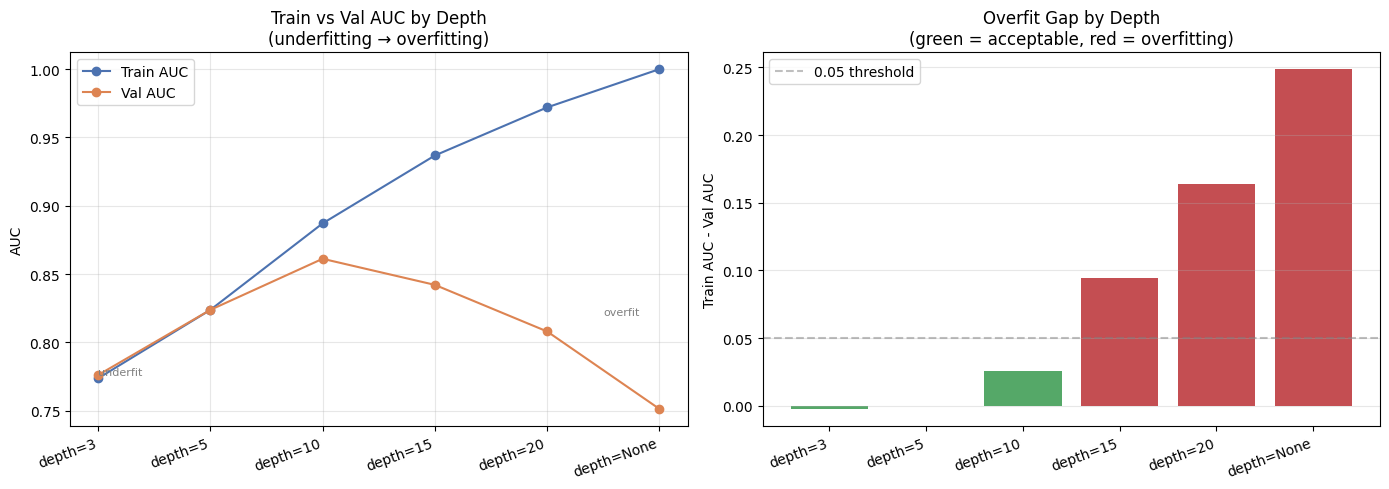

Saved and logged to MLflow


In [15]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

depth_data = {
    "depth=3":    {"train_auc": 0.7737, "val_auc": 0.7761},
    "depth=5":    {"train_auc": 0.8238, "val_auc": 0.8238},
    "depth=10":   {"train_auc": 0.8871, "val_auc": 0.8612},
    "depth=15":   {"train_auc": 0.9368, "val_auc": 0.8421},
    "depth=20":   {"train_auc": 0.9720, "val_auc": 0.8080},
    "depth=None": {"train_auc": 1.0000, "val_auc": 0.7513},
}

df_depth = pd.DataFrame(depth_data).T
df_depth["gap"] = df_depth["train_auc"] - df_depth["val_auc"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = range(len(df_depth))
axes[0].plot(list(x), df_depth["train_auc"], marker="o", label="Train AUC", color="#4C72B0")
axes[0].plot(list(x), df_depth["val_auc"],   marker="o", label="Val AUC",   color="#DD8452")
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(df_depth.index, rotation=20, ha="right")
axes[0].set_title("Train vs Val AUC by Depth\n(underfitting → overfitting)")
axes[0].set_ylabel("AUC")
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].annotate("underfit", xy=(0, 0.7761), fontsize=8, color="gray")
axes[0].annotate("overfit", xy=(4.5, 0.82), fontsize=8, color="gray")

axes[1].bar(df_depth.index, df_depth["gap"], color=["#55A868" if g < 0.05 else "#C44E52" for g in df_depth["gap"]])
axes[1].set_xticklabels(df_depth.index, rotation=20, ha="right")
axes[1].set_title("Overfit Gap by Depth\n(green = acceptable, red = overfitting)")
axes[1].set_ylabel("Train AUC - Val AUC")
axes[1].axhline(y=0.05, color="gray", linestyle="--", alpha=0.5, label="0.05 threshold")
axes[1].legend()
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("dt_depth_analysis.png", dpi=150, bbox_inches="tight")
mlflow.log_artifact("dt_depth_analysis.png")
plt.show()
print("Saved and logged to MLflow")